# Cost-sensitive machine failure triage

This run turns sensor data into a maintenance review queue.

Prediction is only the first step. The task is to decide which machines deserve attention first when inspection time is limited.

The workflow is:

1. Build calibrated failure-risk models.
2. Compare normal model metrics.
3. Convert risk scores into inspection decisions.
4. Pick policies using cost and review capacity.
5. Check the final policy on holdout data.
6. Produce a ranked queue for action.

## Why this is more than a classifier

- In maintenance work, a missed failure and an unnecessary inspection do not have the same cost.
- A normal classifier metric can hide that problem. A model can look good on ROC AUC or F1 and still be hard to use if it floods the team with low-value checks or misses expensive failures.
- So this notebook treats model output as the first step. The output is the inspection policy and ranked queue.

## Notebook design

The repo keeps the implementation in `src/` and `scripts/`.

I keep the notebook focused on the story: what the model learns, how the score becomes a review queue, and what changes when inspection capacity is limited.

In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

INPUT_REPO = Path("/kaggle/input/datasets/patimejia/machine-failure-risk-triage-repo-bundle")
WORK_REPO = Path("/kaggle/working/machine-failure-risk-triage")
KAGGLE_DATA_PATH = Path("/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv")

if INPUT_REPO.exists():
    if WORK_REPO.exists():
        shutil.rmtree(WORK_REPO)
    shutil.copytree(INPUT_REPO, WORK_REPO)
    ROOT = WORK_REPO
else:
    ROOT = Path.cwd()
    if not (ROOT / "scripts").exists() or not (ROOT / "src").exists():
        raise RuntimeError("Repo folder not found. Add the repo bundle dataset as a Kaggle input.")

sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

Path("outputs/metrics").mkdir(parents=True, exist_ok=True)
Path("outputs/artifacts").mkdir(parents=True, exist_ok=True)
Path("outputs/reports").mkdir(parents=True, exist_ok=True)

METRICS_DIR = ROOT / "outputs" / "metrics"
ARTIFACTS_DIR = ROOT / "outputs" / "artifacts"

print("Working repo:", ROOT)
print("Kaggle data exists:", KAGGLE_DATA_PATH.exists())


Working repo: /kaggle/working/machine-failure-risk-triage
Kaggle data exists: True


## Run the lean core pipeline

This executes the reproducible path only.

Archived scenario and small-queue analyses are intentionally excluded from the notebook.

In [2]:
RUN_PIPELINE = True

env = os.environ.copy()
env["PYTHONPATH"] = str(ROOT) + os.pathsep + env.get("PYTHONPATH", "")

commands = [
    [sys.executable, "scripts/run_stage0.py"],
    [sys.executable, "scripts/run_stage1.py"],
    [sys.executable, "scripts/run_stage2.py"],
    [sys.executable, "scripts/run_stage3.py"],
    [sys.executable, "scripts/run_stage4.py"],
    [sys.executable, "scripts/generate_results_report.py"],
    [
        sys.executable, "scripts/predict_queue.py",
        "--input", "data/example/batch_input_sample.csv",
        "--output", "outputs/metrics/batch_prediction_queue.csv",
    ],
]

if RUN_PIPELINE:
    for command in commands:
        print("\n$", " ".join(command))
        subprocess.run(command, check=True, cwd=ROOT, env=env)
else:
    print("Pipeline run skipped.")



$ /usr/bin/python3 scripts/run_stage0.py
Stage 0 complete.
Saved split assignments: /kaggle/working/machine-failure-risk-triage/outputs/metrics/stage0_split_assignments.csv
Saved split metadata: /kaggle/working/machine-failure-risk-triage/outputs/artifacts/stage0_split_metadata.json
       split  rows  positives  negatives  positive_rate
0    holdout   189         79        110       0.417989
1  train_dev   754        314        440       0.416446

$ /usr/bin/python3 scripts/run_stage1.py
             model_name weight_style  ...       ece   ece_std
0   logistic_regression         none  ...  0.048794  0.018220
1   logistic_regression     balanced  ...  0.049198  0.017935
2   logistic_regression         none  ...  0.043025  0.009688
3   logistic_regression         none  ...  0.043193  0.009503
4   logistic_regression     balanced  ...  0.049016  0.014237
5   logistic_regression     balanced  ...  0.048534  0.014117
6           extra_trees         none  ...  0.059166  0.010310
7        

In [3]:
from IPython.display import Markdown, display

def read_csv(name):
    path = METRICS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the pipeline cell first.")
    return pd.read_csv(path)

def read_json(name):
    path = ARTIFACTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the pipeline cell first.")
    return json.loads(path.read_text())

def money(value):
    return f"${float(value):,.0f}"

def pct(value):
    return f"{float(value) * 100:.1f}%"

def clean_label(value):
    return str(value).replace("_", " ").title()

def show_note(text):
    display(Markdown(f"*{text}*"))

def show_table(
    df,
    note=None,
    formats=None,
    pct_cols=None,
    money_cols=None,
    count_cols=None,
    hide_index=True,
):
    """Small display helper for readable notebook tables."""
    view = df.copy()

    formats = dict(formats or {})
    for col in pct_cols or []:
        if col in view.columns:
            formats[col] = "{:.1%}"
    for col in money_cols or []:
        if col in view.columns:
            formats[col] = "${:,.0f}"
    for col in count_cols or []:
        if col in view.columns:
            formats[col] = "{:,.0f}"

    if note:
        show_note(note)

    styler = view.style
    if hide_index:
        styler = styler.hide(axis="index")
    if formats:
        styler = styler.format(formats)
    display(styler)


## Stage 0: train and holdout split

The holdout set is kept untouched until Stage 4. This keeps the final policy check honest.

In [4]:
split_meta = read_json("stage0_split_metadata.json")
split_counts = pd.DataFrame(split_meta["split_counts"])
split_counts


,split,rows,positives,negatives,positive_rate
0,holdout,189,79,110,0.417989
1,train_dev,754,314,440,0.416446


## Stage 1: model comparison

The first pass compares calibrated model candidates using standard ML metrics.

In [5]:
candidates = read_csv("stage1_compact_candidate_results.csv")

cols = [
    "model_name",
    "weight_style",
    "calibration_method",
    "pr_auc",
    "roc_auc",
    "brier",
    "ece",
]

display(
    candidates[cols]
    .sort_values(["pr_auc", "roc_auc"], ascending=[False, False])
    .head(10)
)


,model_name,weight_style,calibration_method,pr_auc,roc_auc,brier,ece
0,logistic_regression,none,sigmoid,0.955381,0.963809,0.073237,0.048794
1,logistic_regression,balanced,sigmoid,0.955339,0.963700,0.073321,0.049198
2,logistic_regression,none,temperature,0.955164,0.963766,0.072111,0.043025
3,logistic_regression,none,none,0.955164,0.963766,0.072125,0.043193
4,logistic_regression,balanced,temperature,0.954974,0.963693,0.073831,0.049016
5,logistic_regression,balanced,none,0.954974,0.963693,0.073861,0.048534
6,extra_trees,none,sigmoid,0.954591,0.962278,0.072900,0.059166
7,extra_trees,balanced,sigmoid,0.954033,0.962565,0.072901,0.065158
8,extra_trees,balanced,none,0.953047,0.959278,0.073758,0.039259
9,extra_trees,balanced,temperature,0.953047,0.959278,0.074369,0.043166


In [6]:
model_view = (
    candidates
    .assign(
        model=lambda df: (
            df["model_name"].map(clean_label) + " / " +
            df["weight_style"].map(clean_label) + " / " +
            df["calibration_method"].map(clean_label)
        )
    )
    .sort_values(["pr_auc", "roc_auc"], ascending=[False, False])
    .loc[:, ["model", "pr_auc", "roc_auc", "brier", "ece"]]
    .head(8)
)

spread = model_view["pr_auc"].max() - model_view["pr_auc"].min()

show_table(
    model_view,
    note=(
        f"The top models are almost tied on PR AUC. "
        f"The spread across this shortlist is only {spread:.4f}, so I do not treat the chart as the main decision."
    ),
    formats={
        "pr_auc": "{:.3f}",
        "roc_auc": "{:.3f}",
        "brier": "{:.3f}",
        "ece": "{:.3f}",
    },
)


*The top models are almost tied on PR AUC. The spread across this shortlist is only 0.0013, so I do not treat the chart as the main decision.*

model,pr_auc,roc_auc,brier,ece
Logistic Regression / None / Sigmoid,0.955,0.964,0.073,0.049
Logistic Regression / Balanced / Sigmoid,0.955,0.964,0.073,0.049
Logistic Regression / None / Temperature,0.955,0.964,0.072,0.043
Logistic Regression / None / None,0.955,0.964,0.072,0.043
Logistic Regression / Balanced / Temperature,0.955,0.964,0.074,0.049
Logistic Regression / Balanced / None,0.955,0.964,0.074,0.049
Extra Trees / None / Sigmoid,0.955,0.962,0.073,0.059
Extra Trees / Balanced / Sigmoid,0.954,0.963,0.073,0.065


## Stage 2: choosing the inspection cutoff

A probability is not yet a maintenance decision.

The cutoff decides how far down the risk list we inspect. Lower cutoffs catch more failures, but they also send more healthy machines to review.

In [7]:
threshold_diag = read_csv("stage2_selected_threshold_diagnostics.csv")

threshold_view = (
    threshold_diag
    .assign(
        model=lambda df: (
            df["model_name"].map(clean_label) + " / " +
            df["weight_style"].map(clean_label) + " / " +
            df["calibration_method"].map(clean_label)
        ),
        inspected=lambda df: df["selected_count"],
        false_alarms=lambda df: df["false_positives"],
        missed_failures=lambda df: df["false_negatives"],
    )
    .loc[:, ["model", "threshold", "inspected", "false_alarms", "missed_failures", "recall", "precision"]]
    .sort_values(["missed_failures", "inspected", "false_alarms"])
    .head(8)
)

show_table(
    threshold_view,
    note=(
        "This table shows the first policy tradeoff: lower thresholds catch every failure, "
        "but they also send more healthy machines into review."
    ),
    formats={
        "threshold": "{:.4f}",
        "recall": "{:.1%}",
        "precision": "{:.1%}",
    },
)


*This table shows the first policy tradeoff: lower thresholds catch every failure, but they also send more healthy machines into review.*

model,threshold,inspected,false_alarms,missed_failures,recall,precision
Logistic Regression / Balanced / Sigmoid,0.0390,594,280,0,100.0%,52.9%
Logistic Regression / None / Sigmoid,0.0385,599,285,0,100.0%,52.4%
Xgboost / None / None,0.0008,609,295,0,100.0%,51.6%
Logistic Regression / Balanced / Isotonic,0.0163,610,296,0,100.0%,51.5%
Logistic Regression / None / Temperature,0.0131,615,301,0,100.0%,51.1%
Logistic Regression / Balanced / Temperature,0.0178,619,305,0,100.0%,50.7%
Logistic Regression / None / Isotonic,0.0125,623,309,0,100.0%,50.4%
Logistic Regression / None / None,0.0109,625,311,0,100.0%,50.2%


## Stage 3: turning risk into an inspection policy

Here the model score becomes a maintenance rule.

The policy is judged by failures found, failures missed, healthy machines reviewed, and proxy net savings. I read this as the practical part of the notebook.

In [8]:
policy_comparison = read_csv("stage3_policy_comparison.csv")

key_cols = [
    "policy_name",
    "selected_count",
    "true_positives",
    "false_positives",
    "false_negatives",
    "recall",
    "precision",
    "total_cost",
    "net_savings",
]
key_cols = [col for col in key_cols if col in policy_comparison.columns]

policy_view = policy_comparison[key_cols].copy()
policy_view["policy_name"] = policy_view["policy_name"].map(clean_label)

metric_cols = [col for col in key_cols if col != "policy_name"]
unique_metric_rows = policy_view[metric_cols].drop_duplicates()

if len(unique_metric_rows) == 1:
    row = unique_metric_rows.iloc[0]
    show_note(
        "The zero-miss and cost-sensitive policies land on the same operating point here. "
        "That is useful: the cost objective did not ask us to miss failures just to save inspections."
    )

    summary = pd.DataFrame(
        {
            "Metric": [
                "Machines reviewed",
                "Failures found",
                "Healthy machines reviewed",
                "Missed failures",
                "Recall",
                "Precision",
                "Net savings",
            ],
            "Result": [
                f"{row.get('selected_count', 0):,.0f}",
                f"{row.get('true_positives', 0):,.0f}",
                f"{row.get('false_positives', 0):,.0f}",
                f"{row.get('false_negatives', 0):,.0f}",
                pct(row.get("recall", 0)),
                pct(row.get("precision", 0)),
                money(row.get("net_savings", 0)),
            ],
        }
    )
    show_table(summary, hide_index=True)
else:
    compact = policy_view.sort_values("net_savings", ascending=False)
    show_table(
        compact,
        note=(
            "When policies differ, this compact table shows the operating tradeoff directly."
        ),
        pct_cols=["recall", "precision"],
        money_cols=["total_cost", "net_savings"],
        count_cols=["selected_count", "true_positives", "false_positives", "false_negatives"],
    )


*The zero-miss and cost-sensitive policies land on the same operating point here. That is useful: the cost objective did not ask us to miss failures just to save inspections.*

Metric,Result
Machines reviewed,594
Failures found,314
Healthy machines reviewed,280
Missed failures,0
Recall,100.0%
Precision,52.9%
Net savings,"$151,060"


In [9]:
frontier = read_csv("stage3_capacity_frontier.csv")

frontier_work = frontier.copy()

frontier_work["Model setup"] = (
    frontier_work["model_name"].map(clean_label) + " / "
    + frontier_work["weight_style"].map(clean_label) + " / "
    + frontier_work["calibration_method"].map(clean_label)
)

frontier_work["Review plan"] = frontier_work["capacity_label"].map(clean_label)

frontier_work["Review plan"] = frontier_work["Review plan"].replace(
    {
        "Top 10Pct Reviewed": "Top 10% reviewed",
        "Top 20Pct Reviewed": "Top 20% reviewed",
        "Top 30Pct Reviewed": "Top 30% reviewed",
        "Top 40Pct Reviewed": "Top 40% reviewed",
        "Top 50Pct Reviewed": "Top 50% reviewed",
        "Train Zero Miss Capacity": "Zero-miss / unconstrained cost",
        "Unconstrained Cost Capacity": "Zero-miss / unconstrained cost",
    }
)

frontier_view = (
    frontier_work
    .assign(
        Reviewed=lambda df: df["selected_count"],
        **{
            "Failures found": lambda df: df["true_positives"],
            "Healthy reviewed": lambda df: df["false_positives"],
            "Missed failures": lambda df: df["false_negatives"],
            "Net savings": lambda df: df["net_savings"],
        },
    )
    .loc[
        :,
        [
            "Review plan",
            "Model setup",
            "Reviewed",
            "Failures found",
            "Healthy reviewed",
            "Missed failures",
            "recall",
            "precision",
            "Net savings",
        ],
    ]
    .rename(columns={"recall": "Recall", "precision": "Precision"})
    .drop_duplicates()
    .sort_values("Reviewed")
    .reset_index(drop=True)
)

frontier_view["Role"] = ""
frontier_view.loc[
    frontier_view["Review plan"].eq("Top 50% reviewed"),
    "Role",
] = "Selected practical policy"

frontier_view = frontier_view[
    [
        "Review plan",
        "Role",
        "Model setup",
        "Reviewed",
        "Failures found",
        "Healthy reviewed",
        "Missed failures",
        "Recall",
        "Precision",
        "Net savings",
    ]
]

show_table(
    frontier_view,
    note=(
        "Capacity is compared on the training side first. Top 10% through top 50% show how the best model setup shifts as review labor changes. "
        "Zero-miss and unconstrained cost are the same point, so they appear once."
    ),
    pct_cols=["Recall", "Precision"],
    money_cols=["Net savings"],
    count_cols=["Reviewed", "Failures found", "Healthy reviewed", "Missed failures"],
)

*Capacity is compared on the training side first. Top 10% through top 50% show how the best model setup shifts as review labor changes. Zero-miss and unconstrained cost are the same point, so they appear once.*

Review plan,Role,Model setup,Reviewed,Failures found,Healthy reviewed,Missed failures,Recall,Precision,Net savings
Top 10% reviewed,,Extra Trees / Balanced / Isotonic,76,76,0,238,24.2%,100.0%,"$37,240"
Top 20% reviewed,,Extra Trees / Balanced / None,151,151,0,163,48.1%,100.0%,"$73,990"
Top 30% reviewed,,Random Forest / Balanced / None,227,220,7,94,70.1%,96.9%,"$107,730"
Top 40% reviewed,,Extra Trees / Balanced / Isotonic,302,273,29,41,86.9%,90.4%,"$133,480"
Top 50% reviewed,Selected practical policy,Logistic Regression / Balanced / Sigmoid,377,297,80,17,94.6%,78.8%,"$144,730"
Zero-miss / unconstrained cost,,Logistic Regression / Balanced / Sigmoid,594,314,280,0,100.0%,52.9%,"$151,060"


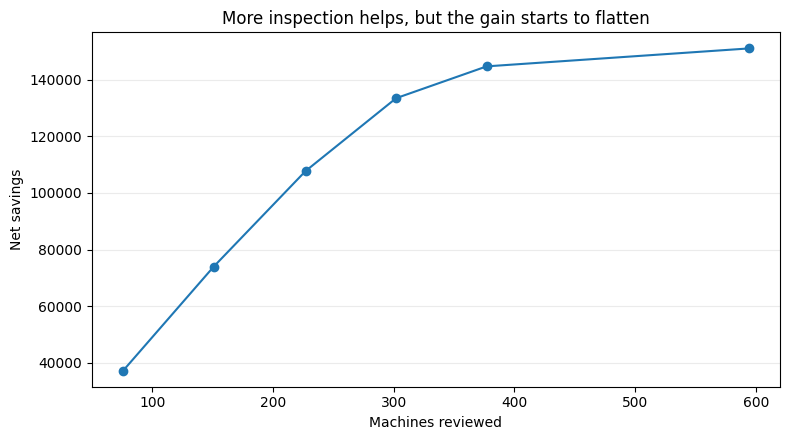

*The curve rises quickly at first, then flattens. That is the staffing argument: beyond a point, more review capacity adds less value per extra inspection.*

In [10]:
frontier_plot = (
    frontier
    .drop_duplicates("capacity_limit")
    .sort_values("capacity_limit")
    .copy()
)

plt.figure(figsize=(8, 4.5))
plt.plot(frontier_plot["capacity_limit"], frontier_plot["net_savings"], marker="o")
plt.xlabel("Machines reviewed")
plt.ylabel("Net savings")
plt.title("More inspection helps, but the gain starts to flatten")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

show_note(
    "The curve rises quickly at first, then flattens. "
    "That is the staffing argument: beyond a point, more review capacity adds less value per extra inspection."
)


## Stage 4: final check on untouched rows

The holdout set is used once, after model and policy choices are already made.

This is where I compare a plain model cutoff with the review policies.

In [11]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.model_selection import StratifiedKFold

def find_project_root():
    start = Path.cwd().resolve()
    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "scripts").exists():
            return path
        nested = path / "machine-failure-risk-triage"
        if (nested / "src").exists() and (nested / "scripts").exists():
            return nested

    raise FileNotFoundError(
        "Could not find project root with src/ and scripts/. "
        f"Current directory: {start}"
    )

project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import METRICS_DIR, SPLIT_COLUMN
from src.data import load_data, remove_exact_duplicates, split_features_target
from src.io_utils import save_table
from src.modeling import fit_candidate, predict_proba

GROUP_COLS_STAGE4_REVIEW = ["model_name", "weight_style", "calibration_method"]

def readable_label(value):
    if "clean_label" in globals():
        return clean_label(value)
    return str(value).replace("_", " ").title()

def stage4_review_plan_label(row):
    labels = {
        "top_10pct_reviewed": "Top 10% reviewed",
        "top_20pct_reviewed": "Top 20% reviewed",
        "top_30pct_reviewed": "Top 30% reviewed",
        "top_40pct_reviewed": "Top 40% reviewed",
        "top_50pct_reviewed": "Top 50% reviewed",
        "train_zero_miss_capacity": "Train-dev zero-miss benchmark",
        "unconstrained_cost_capacity": "Unconstrained cost benchmark",
    }
    value = str(row["capacity_label"])
    return labels.get(value, value.replace("_", " ").title())

def stage4_review_cv_splits(y):
    default_folds = StratifiedKFold().get_n_splits()
    min_class_count = int(pd.Series(y).value_counts().min())
    return min(default_folds, min_class_count)

def build_stage4_review_plan_audit():
    split_path = METRICS_DIR / "stage0_split_assignments.csv"
    frontier_path = METRICS_DIR / "stage3_capacity_frontier.csv"
    out_path = METRICS_DIR / "stage4_review_plan_audit.csv"

    if not split_path.exists():
        raise FileNotFoundError(f"Missing {split_path}. Run Stage 0 first.")

    if not frontier_path.exists():
        raise FileNotFoundError(f"Missing {frontier_path}. Run Stage 3 first.")

    raw_df = load_data()
    clean_df, _ = remove_exact_duplicates(raw_df)
    clean_df = clean_df.reset_index(drop=True)

    split_df = pd.read_csv(split_path)

    train_ids = split_df.loc[
        split_df[SPLIT_COLUMN].eq("train_dev"),
        "row_id",
    ].astype(int)

    holdout_ids = split_df.loc[
        split_df[SPLIT_COLUMN].eq("holdout"),
        "row_id",
    ].astype(int)

    train_df = clean_df.loc[train_ids].copy()
    holdout_df = clean_df.loc[holdout_ids].copy()

    frontier = pd.read_csv(frontier_path)

    percent_rows = frontier[
        frontier["capacity_type"].eq("percent_of_train_dev")
    ].copy()

    if percent_rows.empty:
        raise ValueError("No percent_of_train_dev rows found in stage3_capacity_frontier.csv")

    practical_idx = (
        percent_rows
        .sort_values(
            ["net_savings", "false_negatives", "selected_count"],
            ascending=[False, True, True],
        )
        .index[0]
    )

    percent_rows.loc[:, "role"] = ""
    percent_rows.loc[practical_idx, "role"] = "Selected practical policy"

    benchmark_rows = frontier[
        frontier["capacity_type"].ne("percent_of_train_dev")
    ].copy()

    if not benchmark_rows.empty:
        benchmark_rows.loc[:, "role"] = "Benchmark"

    plans = pd.concat(
        [
            percent_rows.sort_values("selected_count"),
            benchmark_rows.sort_values(["selected_count", "capacity_label"]),
        ],
        ignore_index=True,
        sort=False,
    )

    X_train, y_train = split_features_target(train_df)
    X_holdout, y_holdout = split_features_target(holdout_df)

    folds = stage4_review_cv_splits(y_train)
    model_cache = {}
    score_cache = {}
    rows = []

    for _, plan in plans.iterrows():
        key = tuple(str(plan[col]) for col in GROUP_COLS_STAGE4_REVIEW)

        if key not in model_cache:
            spec = dict(zip(GROUP_COLS_STAGE4_REVIEW, key))

            model_cache[key] = fit_candidate(
                X_train=X_train,
                y_train=y_train,
                calibration_cv=folds,
                **spec,
            )

            y_proba = predict_proba(model_cache[key], X_holdout)

            score_cache[key] = pd.DataFrame({
                "row_id": holdout_df.index.to_numpy(dtype=int),
                "y_true": y_holdout.to_numpy(dtype=int),
                "failure_probability": y_proba,
            })

        selected_rate = float(plan["selected_rate"])
        review_count = int(round(selected_rate * len(score_cache[key])))
        review_count = max(1, min(review_count, len(score_cache[key])))

        ranked = (
            score_cache[key]
            .sort_values(["failure_probability", "row_id"], ascending=[False, True])
            .reset_index(drop=True)
        )

        reviewed = ranked.head(review_count)
        waiting = ranked.iloc[review_count:]

        holdout_failures = int(ranked["y_true"].sum())
        failures_found = int(reviewed["y_true"].sum())
        healthy_reviewed = int(review_count - failures_found)
        missed_failures = int(waiting["y_true"].sum())

        rows.append({
            "review_plan": stage4_review_plan_label(plan),
            "role": str(plan.get("role", "")),
            "model_name": str(plan["model_name"]),
            "weight_style": str(plan["weight_style"]),
            "calibration_method": str(plan["calibration_method"]),
            "reviewed": review_count,
            "holdout_rows": int(len(ranked)),
            "holdout_failures": holdout_failures,
            "failures_found": failures_found,
            "healthy_reviewed": healthy_reviewed,
            "missed_failures": missed_failures,
            "recall": failures_found / holdout_failures if holdout_failures else 0.0,
            "precision": failures_found / review_count if review_count else 0.0,
            "train_dev_selected_count": int(plan["selected_count"]),
            "train_dev_failures_found": int(plan["true_positives"]),
            "train_dev_healthy_reviewed": int(plan["false_positives"]),
            "train_dev_missed_failures": int(plan["false_negatives"]),
            "train_dev_net_savings": float(plan["net_savings"]),
        })

    audit = pd.DataFrame(rows)
    save_table(audit, out_path)

    return audit

stage4_review_plan_audit = build_stage4_review_plan_audit()

review_plan_view = stage4_review_plan_audit.copy()

review_plan_view["Review plan"] = review_plan_view["review_plan"]
review_plan_view["Role"] = review_plan_view["role"].fillna("")
review_plan_view["Model setup"] = (
    review_plan_view["model_name"].map(readable_label) + " / "
    + review_plan_view["weight_style"].map(readable_label) + " / "
    + review_plan_view["calibration_method"].map(readable_label)
)

review_plan_view = review_plan_view.rename(
    columns={
        "reviewed": "Reviewed",
        "failures_found": "Failures found",
        "healthy_reviewed": "Healthy reviewed",
        "missed_failures": "Missed failures",
        "recall": "Recall",
        "precision": "Precision",
        "train_dev_net_savings": "Train-dev proxy net value",
    }
)

ops_cols = [
    "Review plan",
    "Role",
    "Model setup",
    "Reviewed",
    "Failures found",
    "Missed failures",
    "Healthy reviewed",
]

value_cols = [
    "Review plan",
    "Role",
    "Model setup",
    "Recall",
    "Precision",
    "Train-dev proxy net value",
]

show_table(
    review_plan_view[ops_cols],
    note=(
        "Stage 4 final-test audit. Stage 3 chooses the model setup and review limit "
        "on train-development rows; Stage 4 checks that fixed plan once on the final test set. "
        "The benchmark is called train-dev zero-miss because it had zero misses during selection, "
        "not because zero misses are guaranteed on new rows."
    ),
    count_cols=[
        "Reviewed",
        "Failures found",
        "Missed failures",
        "Healthy reviewed",
    ],
)

show_table(
    review_plan_view[value_cols],
    note=(
        "Policy quality and proxy value. Precision alone does not choose the selected practical policy: "
        "a smaller queue can look cleaner while leaving many more failures waiting. "
        "Dollar values are proxy net values from the train-development policy comparison, "
        "not verified savings or ROI."
    ),
    pct_cols=["Recall", "Precision"],
    money_cols=["Train-dev proxy net value"],
)

*Stage 4 final-test audit. Stage 3 chooses the model setup and review limit on train-development rows; Stage 4 checks that fixed plan once on the final test set. The benchmark is called train-dev zero-miss because it had zero misses during selection, not because zero misses are guaranteed on new rows.*

Review plan,Role,Model setup,Reviewed,Failures found,Missed failures,Healthy reviewed
Top 10% reviewed,,Extra Trees / Balanced / Isotonic,19,19,60,0
Top 20% reviewed,,Extra Trees / Balanced / None,38,38,41,0
Top 30% reviewed,,Random Forest / Balanced / None,57,54,25,3
Top 40% reviewed,,Extra Trees / Balanced / Isotonic,76,70,9,6
Top 50% reviewed,Selected practical policy,Logistic Regression / Balanced / Sigmoid,94,76,3,18
Train-dev zero-miss benchmark,Benchmark,Logistic Regression / Balanced / Sigmoid,149,78,1,71
Unconstrained cost benchmark,Benchmark,Logistic Regression / Balanced / Sigmoid,149,78,1,71


*Policy quality and proxy value. Precision alone does not choose the selected practical policy: a smaller queue can look cleaner while leaving many more failures waiting. Dollar values are proxy net values from the train-development policy comparison, not verified savings or ROI.*

Review plan,Role,Model setup,Recall,Precision,Train-dev proxy net value
Top 10% reviewed,,Extra Trees / Balanced / Isotonic,24.1%,100.0%,"$37,240"
Top 20% reviewed,,Extra Trees / Balanced / None,48.1%,100.0%,"$73,990"
Top 30% reviewed,,Random Forest / Balanced / None,68.4%,94.7%,"$107,730"
Top 40% reviewed,,Extra Trees / Balanced / Isotonic,88.6%,92.1%,"$133,480"
Top 50% reviewed,Selected practical policy,Logistic Regression / Balanced / Sigmoid,96.2%,80.9%,"$144,730"
Train-dev zero-miss benchmark,Benchmark,Logistic Regression / Balanced / Sigmoid,98.7%,52.3%,"$151,060"
Unconstrained cost benchmark,Benchmark,Logistic Regression / Balanced / Sigmoid,98.7%,52.3%,"$151,060"


## Batch scoring: maintenance queue

The final output is a ranked queue. This is what an operations team can act on.

In [12]:
queue = read_csv("batch_prediction_queue.csv")

queue_view = (
    queue
    .loc[:, ["risk_rank", "row_id", "failure_probability"]]
    .rename(
        columns={
            "risk_rank": "Queue rank",
            "row_id": "Row id",
            "failure_probability": "Failure risk",
        }
    )
)

show_table(
    queue_view,
    note="The final output is simple: inspect from the top of the queue.",
    pct_cols=["Failure risk"],
    count_cols=["Queue rank", "Row id"],
)


*The final output is simple: inspect from the top of the queue.*

Queue rank,Row id,Failure risk
1,7,95.5%
2,8,70.6%
3,4,32.0%
4,6,18.9%
5,9,9.1%
6,5,3.9%
7,0,3.8%
8,3,2.5%
9,1,0.6%
10,2,0.3%


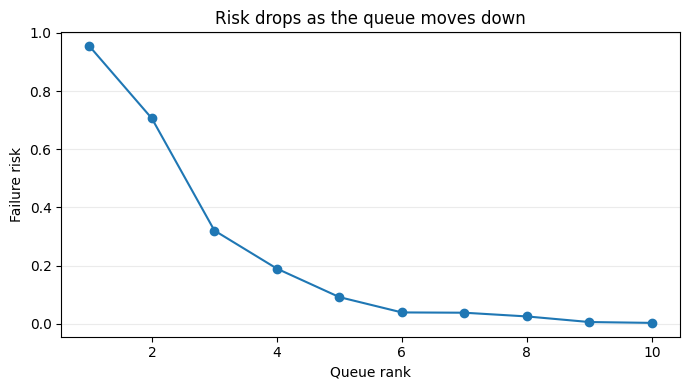

*This chart is useful because it shows how quickly risk falls after the highest-priority machines.*

In [13]:
queue_plot = queue_view.copy()

plt.figure(figsize=(7, 4))
plt.plot(queue_plot["Queue rank"], queue_plot["Failure risk"], marker="o")
plt.xlabel("Queue rank")
plt.ylabel("Failure risk")
plt.title("Risk drops as the queue moves down")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

show_note(
    "This chart is useful because it shows how quickly risk falls after the highest-priority machines."
)


## Conclusion

The output is not a model score. It is a ranked maintenance queue.

I would read the result this way: the model finds risk, then the policy decides how much risk is worth acting on under cost and labor limits.

That distinction matters. A classifier can look strong and still be awkward for maintenance planning. A policy has to say what to inspect, what it costs, and what failures it still misses.